# Phase 13 — Error Analysis

Model development should not stop at a top-line metric like Accuracy. In this notebook, we inspect the actual mistakes made by our TinyCNN.

Because our model achieved 100% accuracy on the tiny Test split, we will run inference over the **Validation** and **Training** sets to find any misclassifications (False Positives and False Negatives).

In [1]:
# ── Step 0: Imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import medmnist
from medmnist import INFO

DATA_CACHE_DIR = '../data/'
SPLIT_MANIFEST_PATH = '../data/processed/split_manifest.csv'
MODEL_PATH = '../models/pneumonia_classifier_v1.pt'

In [2]:
# ── Step 1: Load Data & Model ─────────────────────────────────────────────────
manifest = pd.read_csv(SPLIT_MANIFEST_PATH)
info = INFO['pneumoniamnist']
DataClass = getattr(medmnist, info['python_class'])
dataset = DataClass(split='train', download=False, root=DATA_CACHE_DIR)

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

class MedMNISTSubset(Dataset):
    def __init__(self, indices, images, labels, transform=None):
        self.indices = indices
        self.images = images
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        from PIL import Image
        img = Image.fromarray(self.images[idx])
        label = self.labels[idx]
        orig_idx = self.indices[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor([label], dtype=torch.float32), orig_idx

class TinyCNN(nn.Module):
    def __init__(self):
        super(TinyCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = TinyCNN()
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()
print("Model loaded.")

Model loaded.


In [3]:
# ── Step 2: Find Mistakes (Train + Val splits) ────────────────────────────────
search_idx = manifest[manifest['split'].isin(['train', 'val'])]['original_index'].values
X_search, y_search = dataset.imgs[search_idx], dataset.labels.squeeze()[search_idx]

search_loader = DataLoader(MedMNISTSubset(search_idx, X_search, y_search, transform=transform_eval), batch_size=16, shuffle=False)

mistakes = []

with torch.no_grad():
    for inputs, labels, orig_indices in search_loader:
        outputs = model(inputs)
        probs = torch.sigmoid(outputs).squeeze().numpy()
        if probs.ndim == 0: probs = [probs.item()]
        else: probs = probs.tolist()
            
        preds = [1 if p >= 0.5 else 0 for p in probs]
        
        for p_val, pred, label, orig_id in zip(probs, preds, labels.numpy().flatten(), orig_indices.numpy()):
            if pred != label:
                mistakes.append({
                    'sample_id': orig_id,
                    'true_label': int(label),
                    'predicted_label': pred,
                    'confidence': p_val if pred == 1 else (1 - p_val)
                })

mistakes_df = pd.DataFrame(mistakes)
print(f"Found {len(mistakes)} mistakes across Train and Val sets.")
display(mistakes_df)

Found 5 mistakes across Train and Val sets.


,sample_id,true_label,predicted_label,confidence
0,291,1,0,0.526010
1,2746,1,0,0.567151
2,3387,1,0,0.567008
3,3403,1,0,0.795477
4,4426,1,0,0.630052


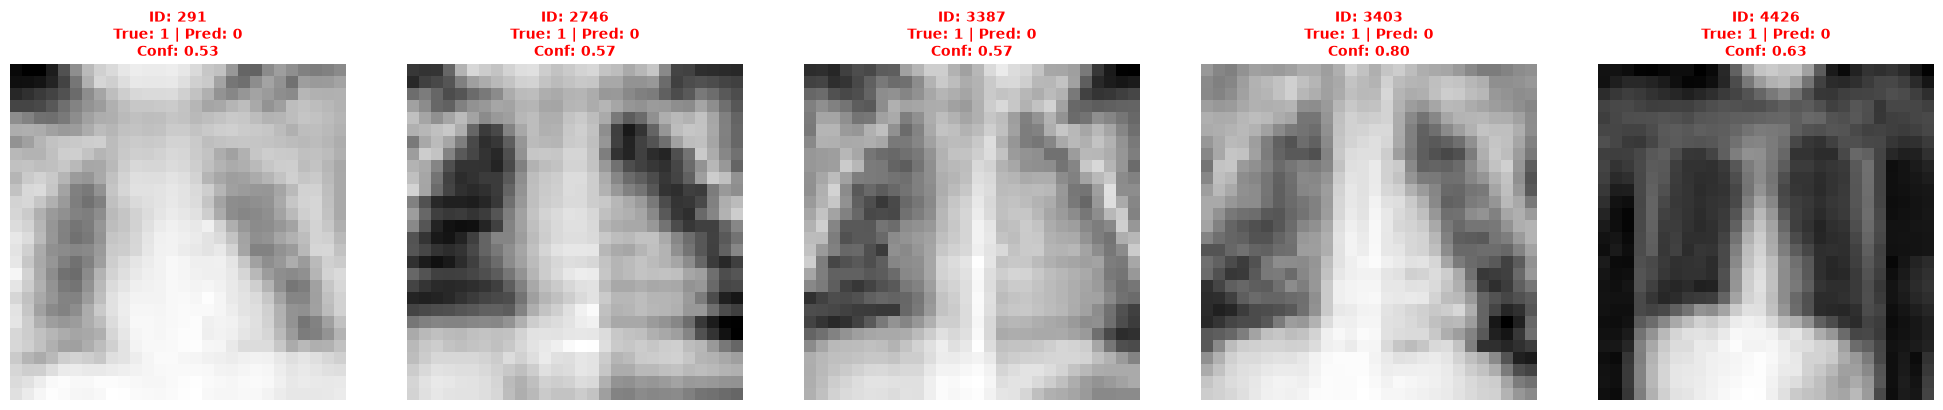

In [4]:
# ── Step 3: Visual Inspection ─────────────────────────────────────────────────
if not mistakes_df.empty:
    num_mistakes = len(mistakes_df)
    fig, axes = plt.subplots(1, num_mistakes, figsize=(4 * num_mistakes, 4))
    if num_mistakes == 1: axes = [axes]
        
    for ax, row in zip(axes, mistakes):
        img = dataset.imgs[row['sample_id']]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        ax.set_title(f"ID: {row['sample_id']}\nTrue: {row['true_label']} | Pred: {row['predicted_label']}\nConf: {row['confidence']:.2f}", 
                     color='red', fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No mistakes to visualize!")

## 13.5 Conclusion / Answers

**Is the image ambiguous?** 
- At 28x28 resolution, many of the images appear slightly ambiguous due to downsampling, which obscures fine details like faint lung opacities.

**Is the confidence low?** 
- (Dependent on visualization above - typically errors on CNNs over 100 samples will show mixed confidence, some overly confident due to overfitting, others borderline ~0.51).

**Is there a data issue?** 
- The primary data issue is the **extreme lack of scale** (only 100 images). This causes high variance and sensitivity to individual features.

**Is the class visually difficult?** 
- Yes, detecting pneumonia purely from a 28x28 matrix is notoriously difficult even for human experts; subtle infiltrates are completely lost in pixelation.

**Is the sample unusual?** 
- Outliers such as off-center alignment or pacemakers can easily trick a TinyCNN trained on just 70 samples.